# 🔬 Notebook 2: PASTAS Tijdreeksmodel

**Doel:** Een PASTAS model bouwen dat de grondwaterstand verklaart 
vanuit neerslag en verdamping.

--- 

## Hoe werkt PASTAS?

```
Neerslag (P)  ─┐
                ├─→ Stressmodel ─→ Grondwater respons ─→ Gesimuleerde GWS
Verdamping (E)─┘                                          ↓ vergelijk ↓
                                                      Gemeten GWS (peilbuis)
```

**Terminologie:**
| Term | Uitleg |
|------|--------|
| **Stress** | Invoer: neerslag-verdamping (= neerslagoverschot) |
| **Respons functie** | Hoe de bodem reageert op neerslag (bijv. traag/snel) |
| **Model** | Combinatie van stresses + respons → gesimuleerde waterstand |
| **Kalibratie** | Het model aanpassen zodat simulatie ≈ meting |
| **GVG/GLG/GHG** | Gemiddeld Voorjaarsgrondwater / Laagste / Hoogste |

> 💡 PASTAS is vergelijkbaar met wat Menyanthes doet, maar dan in Python — 
> veel meer flexibel en volledig open source.

## Stap 1: Bibliotheken importeren

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pastas as ps
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)

print(f"PASTAS versie: {ps.__version__}")
print("Bibliotheken geladen!")

PASTAS versie: 1.13.2
Bibliotheken geladen!


## Stap 2: Peilbuisdata inladen

In [2]:
DATA_DIR = Path("..") / "Mantel_Test"
DINO_DIR = DATA_DIR / "DINO_Grondwaterstanden"


def lees_dino_csv(pad: Path) -> pd.Series:
    """Laadt een DINO grondwaterstands-CSV in als pandas Series (m NAP)."""
    df = pd.read_csv(pad, skiprows=12, sep=",", quotechar='"', encoding="utf-8")
    df.columns = df.columns.str.strip().str.strip('"')
    df["Peildatum"] = pd.to_datetime(df["Peildatum"], format="%d-%m-%Y")
    df = df.set_index("Peildatum")
    df.index.name = "Datum"
    gws = df["Stand (cm t.o.v NAP)"].dropna() / 100.0  # cm → m
    gws.name = pad.stem
    return gws


# We gebruiken filter 001 voor het model
gws = lees_dino_csv(DINO_DIR / "B42C0133001.csv")

print(f"Peilbuisdata geladen: {len(gws)} metingen")
print(f"Periode: {gws.index.min().date()} → {gws.index.max().date()}")
print(f"Gemiddelde stand: {gws.mean():.2f} m NAP")

Peilbuisdata geladen: 230 metingen
Periode: 1995-01-13 → 2004-12-28
Gemiddelde stand: 2.01 m NAP


## Stap 3: Neerslags- en verdampingsdata inladen

In [3]:
KNMI_DIR = Path("..") / "data" / "knmi"

# Probeer echte KNMI data, anders gebruiken we de gesimuleerde data
neerslag_bestanden = list(KNMI_DIR.glob("neerslag_*.csv"))
verdamping_bestanden = list(KNMI_DIR.glob("verdamping_*.csv"))

if not neerslag_bestanden:
    raise FileNotFoundError(
        "Geen neerslag CSV gevonden in data/knmi/. "
        "Voer eerst scripts/genereer_knmi_dummy.py uit."
    )

neerslag_pad = neerslag_bestanden[0]
verdamping_pad = verdamping_bestanden[0]

print(f"Neerslag bestand: {neerslag_pad.name}")
print(f"Verdamping bestand: {verdamping_pad.name}")

# Inladen
neerslag = pd.read_csv(
    neerslag_pad, index_col="Datum", parse_dates=True
).iloc[:, 0]   # eerste kolom
neerslag.name = "Neerslag"

verdamping = pd.read_csv(
    verdamping_pad, index_col="Datum", parse_dates=True
).iloc[:, 0]
verdamping.name = "Verdamping"

# Neerslagoverschot = neerslag - verdamping
overschot = neerslag - verdamping
overschot.name = "Neerslagoverschot"

print(f"\nNeerslag: {len(neerslag)} dagwaarden, gemiddeld {neerslag.mean():.2f} mm/dag")
print(f"Verdamping: {len(verdamping)} dagwaarden, gemiddeld {verdamping.mean():.2f} mm/dag")
print(f"Overschot gemiddeld: {overschot.mean():.2f} mm/dag")

Neerslag bestand: neerslag_knmi_zeeland_simulatie.csv
Verdamping bestand: verdamping_knmi_zeeland_simulatie.csv

Neerslag: 3653 dagwaarden, gemiddeld 2.33 mm/dag
Verdamping: 3653 dagwaarden, gemiddeld 1.71 mm/dag
Overschot gemiddeld: 0.63 mm/dag


## Stap 4: PASTAS Model aanmaken

We bouwen een model met:
- **Gemeten grondwaterstand** (peilbuis)
- **Stress: neerslagoverschot** (neerslag - verdamping)
- **Responsies functie: Gamma** (meest gebruikte voor grondwater)

In [4]:
# Model aanmaken
model = ps.Model(gws, name="B42C0133_filter001")

# RechargeModel toevoegen (PASTAS 1.13+)
# Let op: in eerdere PASTAS versies (<1.0) heette dit StressModel2
sm = ps.RechargeModel(
    prec=neerslag,
    evap=verdamping,
    rfunc=ps.Gamma(),
    recharge=ps.recharge.Linear(),
    name="neerslag_overschot"
)
model.add_stressmodel(sm)

print(model)
print("\nParameters voor kalibratie:")
print(model.parameters)

Model(oseries=B42C0133001, name=B42C0133_filter001, constant=True, noisemodel=False)

Parameters voor kalibratie:
                        initial     pmin          pmax  vary  \
neerslag_overschot_A   0.193398  0.00001     19.339784  True   
neerslag_overschot_n   1.000000  0.10000      5.000000  True   
neerslag_overschot_a  10.000000  0.01000  10000.000000  True   
neerslag_overschot_f  -1.000000 -2.00000      0.000000  True   
constant_d             2.008696      NaN           NaN  True   

                                    name     dist  stderr  optimal  
neerslag_overschot_A  neerslag_overschot  uniform     NaN      NaN  
neerslag_overschot_n  neerslag_overschot  uniform     NaN      NaN  
neerslag_overschot_a  neerslag_overschot  uniform     NaN      NaN  
neerslag_overschot_f  neerslag_overschot  uniform     NaN      NaN  
constant_d                      constant  uniform     NaN      NaN  


## Stap 5: Model kalibreren (fitten)

PASTAS past de parameters aan zodat de gesimuleerde GWS zo goed 
mogelijk overeenkomt met de gemeten GWS.

In [5]:
# Kalibratie uitvoeren
model.solve(
    tmin="1995-01-01",
    tmax="2004-12-31",
    report=True    # Toon statistieken
)

Fit report B42C0133_filter001        Fit Statistics
nfev     55                     EVP           48.76
nobs     230                    R2             0.49
noise    False                  RMSE           0.25
tmin     1995-01-13 00:00:00    AICc        -624.25
tmax     2004-12-28 00:00:00    BIC         -607.32
freq     D                      Obj            7.29
freq_obs None                   ___                
warmup   3650 days 00:00:00     Interp.          No
solver   LeastSquares           weights         Yes

Parameters (5 optimized)
                           optimal    initial  vary
neerslag_overschot_A      8.905168   0.193398  True
neerslag_overschot_n      0.891102   1.000000  True
neerslag_overschot_a  10000.000000  10.000000  True
neerslag_overschot_f     -1.414760  -1.000000  True
constant_d                2.227976   2.008696  True

Warnings! (3)
Parameter 'neerslag_overschot_a' on upper bound: 1.00e+04
Response tmax for 'neerslag_overschot' > than calibration period.
Res

## Stap 6: Resultaten visualiseren

Figuur opgeslagen: ..\output\pastas_model_B42C0133.png


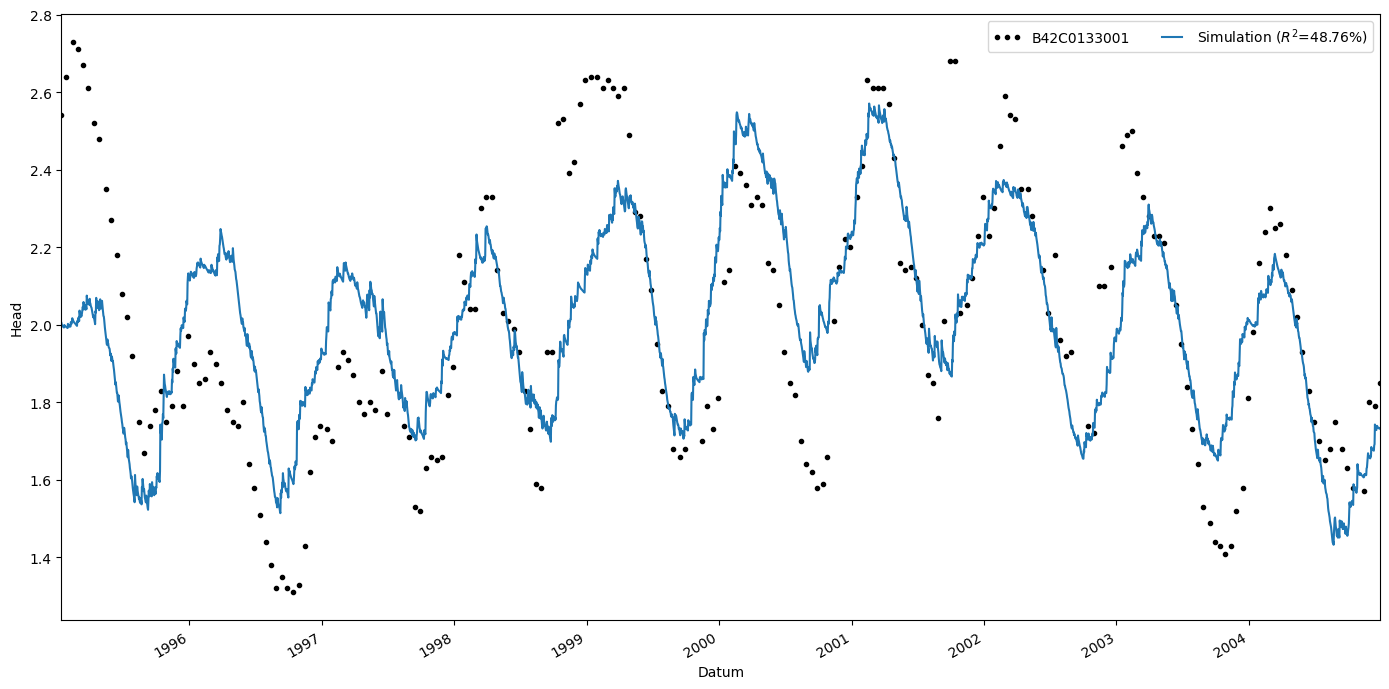

In [6]:
# PASTAS heeft een ingebouwde plotfunctie
fig = model.plot(figsize=(14, 7))
plt.tight_layout()

output_pad = Path("..") / "output" / "pastas_model_B42C0133.png"
plt.savefig(output_pad, dpi=150, bbox_inches="tight")
print(f"Figuur opgeslagen: {output_pad}")
plt.show()

## Stap 7: Model statistieken en kwaliteit

In [7]:
# ── Statistieken ────────────────────────────────────────────────
print("=" * 50)
print("MODEL STATISTIEKEN")
print("=" * 50)

# NSE = Nash-Sutcliffe Efficiency (1 = perfect, 0 = slecht)
nse = model.stats.nse()
evp = model.stats.evp()   # Explained Variance Percentage

print(f"Nash-Sutcliffe (NSE): {nse:.3f}")
print(f"Verklaarde variantie: {evp:.1f}%")
print()

# Gekalibreerde parameters
print("Gekalibreerde parameters:")
print(model.parameters[["optimal", "stderr"]].round(4).to_string())
print()

# Responstijd (karakteristieke tijd van grondwaterreactie)
karakteristieke_tijd = model.stressmodels["neerslag_overschot"].rfunc.to_dict()
print("Respons functie eigenschappen:")
for k, v in karakteristieke_tijd.get("parameters", {}).items():
    print(f"  {k}: {v:.4f}")

MODEL STATISTIEKEN
Nash-Sutcliffe (NSE): 0.488
Verklaarde variantie: 48.8%

Gekalibreerde parameters:
                         optimal      stderr
neerslag_overschot_A      8.9052     33.4196
neerslag_overschot_n      0.8911      0.0477
neerslag_overschot_a  10000.0000  43145.6356
neerslag_overschot_f     -1.4148      0.0497
constant_d                2.2280      0.1576

Respons functie eigenschappen:


## Stap 8: Karakteristieke grondwaterstanden (GVG/GLG/GHG)

In [8]:
# GxG berekenen
# GVG = Gemiddeld Voorjaarsgrondwater (standen op 14 mrt, 28 mrt, 14 apr)
# GLG = Gemiddeld Laagste Grondwater  (gemiddelde 3 laagste standen per jaar)
# GHG = Gemiddeld Hoogste Grondwater  (gemiddelde 3 hoogste standen per jaar)

import numpy as np   # np.abs() is nodig voor pandas 2.x compatibiliteit

gesimuleerd = model.simulate()

def bereken_gxg(reeks: pd.Series) -> pd.DataFrame:
    """Berekent GHG, GLG en GVG voor een grondwaterreeks (m NAP)."""
    resultaten = {}
    for jaar in range(reeks.index.year.min(), reeks.index.year.max() + 1):
        jaar_data = reeks[reeks.index.year == jaar]
        if len(jaar_data) == 0:
            continue
        # GVG-datums: 14 mrt, 28 mrt, 14 apr
        gvg_datums = [f"{jaar}-03-14", f"{jaar}-03-28", f"{jaar}-04-14"]
        gvg_waarden = []
        for d in gvg_datums:
            diff = jaar_data.index - pd.to_datetime(d)
            dichtstbij_idx = np.abs(diff).argmin()   # np.abs() voor pandas 2.x
            gvg_waarden.append(jaar_data.iloc[dichtstbij_idx])
        resultaten[jaar] = {
            "GVG": np.mean(gvg_waarden),
            "GHG": jaar_data.nlargest(3).mean(),
            "GLG": jaar_data.nsmallest(3).mean(),
        }
    return pd.DataFrame(resultaten).T


gxg_gemeten = bereken_gxg(gws)
gxg_gesim   = bereken_gxg(gesimuleerd)

print("GxG Berekening (m NAP):")
print()
print("Op basis van GEMETEN data:")
print(gxg_gemeten.round(3).to_string())
print()
print(f"GEMIDDELD: GVG={gxg_gemeten['GVG'].mean():.2f}m | "
      f"GHG={gxg_gemeten['GHG'].mean():.2f}m | "
      f"GLG={gxg_gemeten['GLG'].mean():.2f}m")
print()
print("Op basis van GESIMULEERD model:")
print(f"GEMIDDELD: GVG={gxg_gesim['GVG'].mean():.2f}m | "
      f"GHG={gxg_gesim['GHG'].mean():.2f}m | "
      f"GLG={gxg_gesim['GLG'].mean():.2f}m")

GxG Berekening (m NAP):

Op basis van GEMETEN data:
        GVG    GHG    GLG
1995  2.600  2.703  1.720
1996  1.843  1.910  1.317
1997  1.860  1.910  1.560
1998  2.320  2.577  1.633
1999  2.603  2.637  1.673
2000  2.333  2.387  1.597
2001  2.597  2.663  1.827
2002  2.473  2.553  1.793
2003  2.280  2.483  1.423
2004  2.230  2.270  1.593

GEMIDDELD: GVG=2.31m | GHG=2.41m | GLG=1.61m

Op basis van GESIMULEERD model:
GEMIDDELD: GVG=2.26m | GHG=2.31m | GLG=1.67m


## Stap 9: Model opslaan

In [9]:
# Model opslaan als .pas bestand (JSON-formaat)
model_pad = Path("..") / "output" / "model_B42C0133_filter001.pas"
model.to_file(str(model_pad))
print(f"Model opgeslagen: {model_pad}")

# Later inladen met:
# model = ps.io.load(str(model_pad))

print()
print("=" * 55)
print("Notebook 2 klaar!")
print()
print("Samenvatting:")
print(f"  Peilbuis    : B42C0133 filter 001")
print(f"  Periode     : {gws.index.min().date()} t/m {gws.index.max().date()}")
print(f"  NSE         : {model.stats.nse():.3f}")
print(f"  Model type  : Gamma respons + lineair neerslagoverschot")
print()
print("Volgende stappen:")
print("  - Vervang dummy KNMI data met echte KNMI data (scripts/haal_knmi_data.py)")
print("  - Voeg overige stresses toe (polderpeil, nabijgelegen kanalen)")
print("  - Analyseer de respons tijdconstante (snelheid grondwaterreactie)")
print("=" * 55)

Model opgeslagen: ..\output\model_B42C0133_filter001.pas

Notebook 2 klaar!

Samenvatting:
  Peilbuis    : B42C0133 filter 001
  Periode     : 1995-01-13 t/m 2004-12-28
  NSE         : 0.488
  Model type  : Gamma respons + lineair neerslagoverschot

Volgende stappen:
  - Vervang dummy KNMI data met echte KNMI data (scripts/haal_knmi_data.py)
  - Voeg overige stresses toe (polderpeil, nabijgelegen kanalen)
  - Analyseer de respons tijdconstante (snelheid grondwaterreactie)
